In [1]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

fatal: destination path 'ceam_task_1' already exists and is not an empty directory.


In [2]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-11 19:51:46.024240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781207506.046411   17771 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781207506.053702   17771 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781207506.071935   17771 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781207506.071956   17771 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781207506.071959   17771 computation_placer.cc:177] computation placer alr

In [3]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [4]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [5]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [6]:
def create_baseline_model(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', 
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(5, activation='softmax')
    ])
    
    return model
model = create_baseline_model(dropout_rate=0.5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781207510.550154   17771 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781207510.555323   17771 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
lr_values = [0.0001, 0.0005,0.001, 0.005, 0.01]
lr_results = {}

for lr in lr_values:
    model = create_baseline_model(dropout_rate=0.5)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        train_images, train_labels,
        batch_size=8,
        epochs=50,
        validation_data=(val_images, val_labels),
        verbose=0
    )
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    lr_results[lr] = test_acc * 100
    print(f"Adam (lr={lr}): Test Accuracy = {test_acc*100:.2f}%")

I0000 00:00:1781207512.917635   17816 service.cc:152] XLA service 0x7d498024acf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781207512.917666   17816 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781207512.917670   17816 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781207513.182560   17816 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781207515.951145   17816 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-11 19:51:57.088853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 19:51:57.232950: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured t

Adam (lr=0.0001): Test Accuracy = 52.63%
Adam (lr=0.0005): Test Accuracy = 68.42%
Adam (lr=0.001): Test Accuracy = 84.21%
Adam (lr=0.005): Test Accuracy = 57.89%
Adam (lr=0.01): Test Accuracy = 15.79%


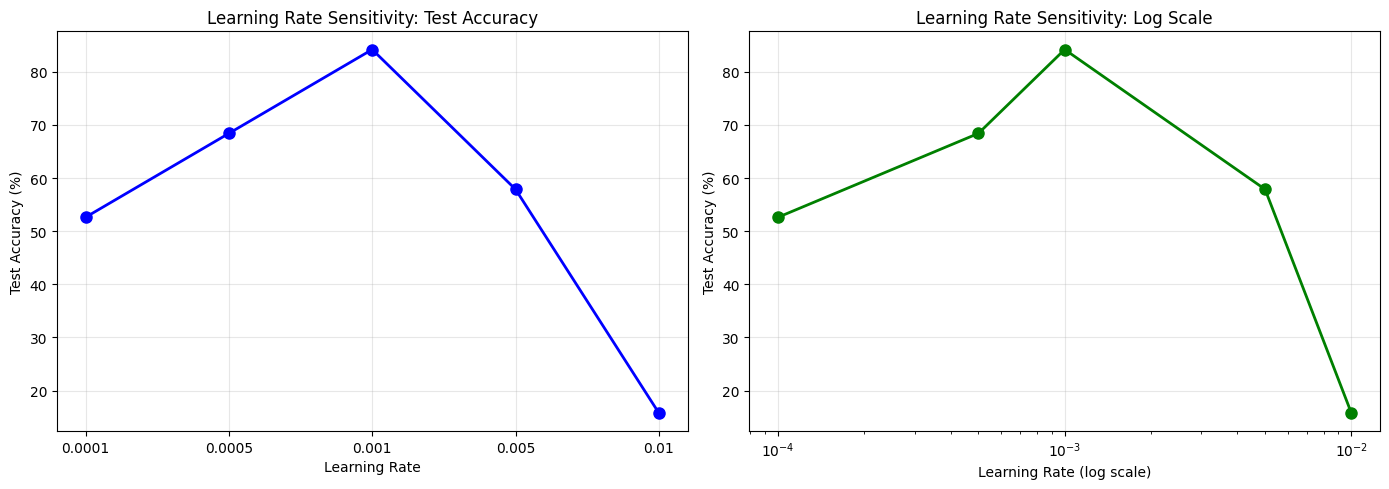

In [8]:
# Create comparison plot for learning rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lr_values = [0.0001, 0.0005,0.001, 0.005, 0.01]
test_accs = [52.63, 68.42,84.21, 57.89, 15.79]
axes[0].plot([str(lr) for lr in lr_values], test_accs, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Learning Rate Sensitivity: Test Accuracy')
axes[0].grid(alpha=0.3)

# Also plot as log scale to see the pattern better
axes[1].semilogx(lr_values, test_accs, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Learning Rate Sensitivity: Log Scale')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_2_lr_sensitivity.png', dpi=150)
plt.show()

In [24]:
base_model = create_baseline_model(dropout_rate=0.5)
initial_weights = base_model.get_weights()

In [25]:
def step_decay(epoch):
    if epoch < 15:
        return 0.001
    elif epoch < 30:
        return 0.0005
    else:
        return 0.0001

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(step_decay)

model_step = create_baseline_model(dropout_rate=0.5)
model_step.set_weights(initial_weights)

model_step.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_step = model_step.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    callbacks=[lr_scheduler],
    verbose=0
)

test_loss_step, test_acc_step = model_step.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Step Decay Test Accuracy: {test_acc_step*100:.2f}%")

Step Decay Test Accuracy: 47.37%


In [26]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

model_plateau = create_baseline_model(dropout_rate=0.5)
model_plateau.set_weights(initial_weights)

model_plateau.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_plateau = model_plateau.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    callbacks=[reduce_lr],
    verbose=0
)

test_loss_plateau, test_acc_plateau = model_plateau.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"ReduceLROnPlateau Test Accuracy: {test_acc_plateau*100:.2f}%")

ReduceLROnPlateau Test Accuracy: 57.89%


In [27]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=550
)

model_cosine = create_baseline_model(dropout_rate=0.5)
model_cosine.set_weights(initial_weights)
model_cosine.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cosine = model_cosine.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_cosine, test_acc_cosine = model_cosine.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Cosine Decay Test Accuracy: {test_acc_cosine*100:.2f}%")

Cosine Decay Test Accuracy: 73.68%


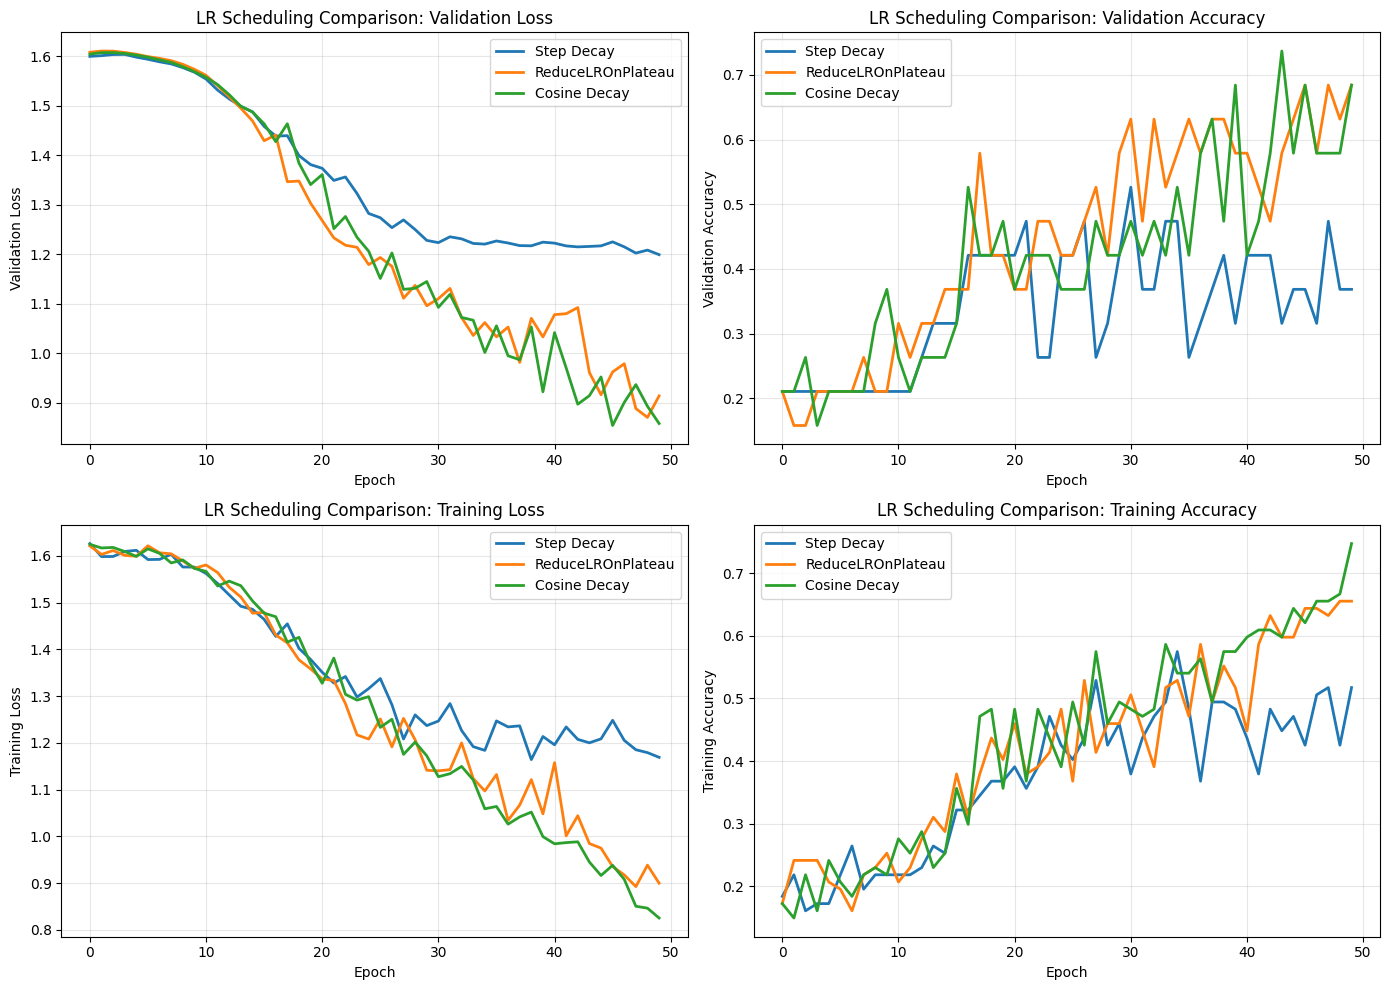

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Loss
axes[0, 0].plot(history_step.history['val_loss'], label='Step Decay', linewidth=2)
axes[0, 0].plot(history_plateau.history['val_loss'], label='ReduceLROnPlateau', linewidth=2)
axes[0, 0].plot(history_cosine.history['val_loss'], label='Cosine Decay', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].set_title('LR Scheduling Comparison: Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation Accuracy
axes[0, 1].plot(history_step.history['val_accuracy'], label='Step Decay', linewidth=2)
axes[0, 1].plot(history_plateau.history['val_accuracy'], label='ReduceLROnPlateau', linewidth=2)
axes[0, 1].plot(history_cosine.history['val_accuracy'], label='Cosine Decay', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('LR Scheduling Comparison: Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Training Loss
axes[1, 0].plot(history_step.history['loss'], label='Step Decay', linewidth=2)
axes[1, 0].plot(history_plateau.history['loss'], label='ReduceLROnPlateau', linewidth=2)
axes[1, 0].plot(history_cosine.history['loss'], label='Cosine Decay', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('LR Scheduling Comparison: Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Training Accuracy
axes[1, 1].plot(history_step.history['accuracy'], label='Step Decay', linewidth=2)
axes[1, 1].plot(history_plateau.history['accuracy'], label='ReduceLROnPlateau', linewidth=2)
axes[1, 1].plot(history_cosine.history['accuracy'], label='Cosine Decay', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Training Accuracy')
axes[1, 1].set_title('LR Scheduling Comparison: Training Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()